dataset : https://www.kaggle.com/datasets/fabdelja/autism-screening-for-toddlers?fbclid=IwY2xjawN1mENleHRuA2FlbQIxMABicmlkETFNV0tEN3VTVDRzREV2cHRuAR5Ri9YpwapRMsiL5FM43HpLFpMrQD3Jg32E-uF7-gJ-f2AbODbRBV4uXIPfoQ_aem_ggpj-cb_FKIREQrv4jY2Yg

**Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
import joblib
import json
import os

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
print("All imports successful.")

All imports successful.


 **Load Dataset**




In [ ]:
!gdown --id 1s-mUI45KZA_Erc4fBQd3Mq9N8Vcee-BP

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1s-mUI45KZA_Erc4fBQd3Mq9N8Vcee-BP
To: /content/Toddler Autism dataset July 2018 (1).csv
100% 70.1k/70.1k [00:00<00:00, 79.5MB/s]


In [ ]:
DATA_PATH = "/content/Toddler Autism dataset July 2018 (1).csv"

data = pd.read_csv(DATA_PATH)

#Strip trailing whitespace from column names.
data.columns = data.columns.str.strip()

print("Shape:", data.shape)
print("\nColumn names:", data.columns.tolist())
data.info()

Shape: (1054, 19)

Column names: ['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     105

**Missing Values & Basic EDA**

In [ ]:
print("Missing values:\n", data.isnull().sum())
print("\nFirst 5 rows:")
data.head()

Missing values:
 Case_No                   0
A1                        0
A2                        0
A3                        0
A4                        0
A5                        0
A6                        0
A7                        0
A8                        0
A9                        0
A10                       0
Age_Mons                  0
Qchat-10-Score            0
Sex                       0
Ethnicity                 0
Jaundice                  0
Family_mem_with_ASD       0
Who completed the test    0
Class/ASD Traits          0
dtype: int64

First 5 rows:


,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [ ]:
print("Target Distribution:")
print(data["Class/ASD Traits"].value_counts())
print("\nImbalance ratio (ASD Yes / No):",
      round(data["Class/ASD Traits"].value_counts()["Yes"] /
            data["Class/ASD Traits"].value_counts()["No"], 3))

print("\nCategorical unique values:")
for col in data.select_dtypes(include="object").columns:
    print(f"  {col}: {data[col].unique().tolist()}")

Target Distribution:
Class/ASD Traits
Yes    728
No     326
Name: count, dtype: int64

Imbalance ratio (ASD Yes / No): 2.233

Categorical unique values:
  Sex: ['f', 'm']
  Ethnicity: ['middle eastern', 'White European', 'Hispanic', 'black', 'asian', 'south asian', 'Native Indian', 'Others', 'Latino', 'mixed', 'Pacifica']
  Jaundice: ['yes', 'no']
  Family_mem_with_ASD: ['no', 'yes']
  Who completed the test: ['family member', 'Health Care Professional', 'Health care professional', 'Self', 'Others']
  Class/ASD Traits: ['No', 'Yes']


**Data Cleaning**


Dropped leakage and irrelevant columns.
Fixed dirty categorical data in Who completed the test (two spellings of the same value).

In [ ]:
# FIX 1: Drop Case_No (row ID) and Qchat-10-Score (data leakage —
# it is the exact sum of A1..A10, so it perfectly predicts the target).
data = data.drop(columns=["Case_No", "Qchat-10-Score"])

# FIX 2: Normalise 'Who completed the test'.
# 'Health Care Professional' and 'Health care professional' are the same.
data["Who completed the test"] = (
    data["Who completed the test"].str.strip().str.lower().str.title()
)
print("'Who completed the test' after cleaning:")
print(data["Who completed the test"].value_counts())
print("\nShape after cleaning:", data.shape)

'Who completed the test' after cleaning:
Who completed the test
Family Member               1018
Health Care Professional      29
Self                           4
Others                         3
Name: count, dtype: int64

Shape after cleaning: (1054, 17)


 **Chi-Square Hypothesis Tests**

Chi-Squre Test

1.
H0: There is no association between Sex and ASD Traits

H1: There is an association between Sex and ASD

2.
H0: There is no association between Jaundice and ASD Traits

H1: There is an association between Jaundice and ASD Traits

3.
H0: There is no association between having a family member with ASD and ASD Traits

H1: There is an association between having a family member with ASD and ASD Traits

4.
H0: There is no association between Ethnicity and ASD Traits

H1: There is an association between Ethnicity and ASD Traits

5.
H0: There is no association between Who completed the test and ASD Traits

H1: There is an association between Who completed the test and ASD Traits


In [ ]:
def chi_square_test(col_name, target_col, df, alpha=0.05):
    """Run chi-square test and return results."""
    ct = pd.crosstab(df[col_name], df[target_col])
    chi2_stat, p_val, dof, expected = stats.chi2_contingency(np.array(ct))
    critical = stats.chi2.ppf(1 - alpha, dof)
    reject = chi2_stat > critical
    print(f"\nH0: No association between '{col_name}' and ASD Traits")
    print(f"  Chi2={chi2_stat:.4f}  p={p_val:.6f}  df={dof}  critical={critical:.4f}")
    print(f"  => {'Reject H0 — significant association' if reject else 'Fail to reject H0'}")
    return chi2_stat, p_val, reject

print("=" * 60)
print("Chi-Square Tests")
print("=" * 60)

chi_square_test("Sex",                   "Class/ASD Traits", data)
chi_square_test("Jaundice",              "Class/ASD Traits", data)
chi_square_test("Family_mem_with_ASD",   "Class/ASD Traits", data)
chi_square_test("Ethnicity",             "Class/ASD Traits", data)
chi_square_test("Who completed the test","Class/ASD Traits", data)

Chi-Square Tests

H0: No association between 'Sex' and ASD Traits
  Chi2=14.0436  p=0.000179  df=1  critical=3.8415
  => Reject H0 — significant association

H0: No association between 'Jaundice' and ASD Traits
  Chi2=5.4270  p=0.019827  df=1  critical=3.8415
  => Reject H0 — significant association

H0: No association between 'Family_mem_with_ASD' and ASD Traits
  Chi2=0.1209  p=0.728014  df=1  critical=3.8415
  => Fail to reject H0

H0: No association between 'Ethnicity' and ASD Traits
  Chi2=43.5713  p=0.000004  df=10  critical=18.3070
  => Reject H0 — significant association

H0: No association between 'Who completed the test' and ASD Traits
  Chi2=1.4153  p=0.701949  df=3  critical=7.8147
  => Fail to reject H0


(np.float64(1.4153131283157896), np.float64(0.7019492073054112), np.False_)

**Interpretation:**

  Sex             : Significant (p<0.001). Males ~2.7x more likely ASD-positive.
                    Well-established epidemiological finding.

  Jaundice        : Significant (p=0.020). Neonatal jaundice linked to
                    neurodevelopmental conditions in literature.

  Family_mem_ASD  : NOT significant (p=0.728). Chi-square lacks power here
                    due to small 'yes' subgroup (n=170). Does not mean
                    family history is clinically irrelevant — just
                    insufficient evidence in this dataset.

  Ethnicity       : Highly significant but reflects unequal group sizes
                    and cultural reporting differences, NOT biological cause.

  Who completed   : NOT significant (p=0.701949). Screening results are
                    consistent regardless of respondent — good reliability.

**Encoding Features**

In [ ]:
# Binary encoding — simple lookup, no information from target used.
data["Sex"]                 = data["Sex"].map({"f": 0, "m": 1})
data["Jaundice"]            = data["Jaundice"].map({"no": 0, "yes": 1})
data["Family_mem_with_ASD"] = data["Family_mem_with_ASD"].map({"no": 0, "yes": 1})
data["Class/ASD Traits"]    = data["Class/ASD Traits"].map({"No": 0, "Yes": 1})

print("Encoded sample:")
data[["Sex", "Jaundice", "Family_mem_with_ASD", "Class/ASD Traits"]].head()

Encoded sample:


,Sex,Jaundice,Family_mem_with_ASD,Class/ASD Traits
0,0,1,0,0
1,1,1,0,1
2,1,1,0,1
3,1,0,0,1
4,0,0,1,1


**Feature Selection Rationale**

In [ ]:
# Point-biserial correlation: appropriate for binary features vs binary target.
# NOTE: This is run on the full dataset (before train/test split) for
# EXPLORATORY and REPORTING purposes only. No transformer or model is fitted
# here, so this does not introduce data leakage into the trained classifier.
# Feature selection (FEATURE_COLS) is fixed by domain reasoning in this cell
# and applied after the split — which is the correct leakage-free order.

y_all = data["Class/ASD Traits"]
A_COLS = [f"A{i}" for i in range(1, 11)]
check_cols = A_COLS + ["Sex", "Jaundice", "Family_mem_with_ASD", "Age_Mons"]

print("Point-Biserial Correlation with ASD target:")
print(f"{'Feature':<22} {'r':>8} {'p-value':>12} {'Parent-answerable':>18}")
print("-" * 65)

parent_answerable = {
    "A1":True,"A2":True,"A3":True,"A4":True,"A5":True,
    "A6":True,"A7":True,"A8":True,"A9":True,"A10":True,
    "Sex":True,"Jaundice":False,"Family_mem_with_ASD":True,"Age_Mons":False
}

for col in check_cols:
    r, p = stats.pointbiserialr(data[col], y_all)
    pa = "Yes" if parent_answerable[col] else "No (medical/numeric)"
    print(f"  {col:<20} {r:>8.4f} {p:>12.2e} {pa:>18}")

Point-Biserial Correlation with ASD target:
Feature                       r      p-value  Parent-answerable
-----------------------------------------------------------------
  A1                     0.5038     6.34e-69                Yes
  A2                     0.4635     3.04e-57                Yes
  A3                     0.4097     6.33e-44                Yes
  A4                     0.5052     2.34e-69                Yes
  A5                     0.5633     2.77e-89                Yes
  A6                     0.5694     1.27e-91                Yes
  A7                     0.5632     3.08e-89                Yes
  A8                     0.4272     5.47e-48                Yes
  A9                     0.5773     1.02e-94                Yes
  A10                    0.1798     4.12e-09                Yes
  Sex                    0.1177     1.29e-04                Yes
  Jaundice               0.0741     1.62e-02 No (medical/numeric)
  Family_mem_with_ASD   -0.0135     6.61e-01            

In [ ]:
FEATURE_COLS = A_COLS + ["Sex"]
print("Final feature vector:", FEATURE_COLS)
print("Count:", len(FEATURE_COLS))

X = data[FEATURE_COLS].copy()
y = data["Class/ASD Traits"].copy()
print("\nX shape:", X.shape, "  y shape:", y.shape)

Final feature vector: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Sex']
Count: 11

X shape: (1054, 11)   y shape: (1054,)


SELECTED FEATURES (11, all parent-answerable):

  A1-A10 : All 10 Q-CHAT-10 questions. These ARE the validated
           instrument — dropping any reduces clinical validity.

  Sex    : Significant (p<0.001). r=0.118. Parent-answerable.


EXCLUDED FEATURES :

  Qchat-10-Score     : DATA LEAKAGE (sum of A1..A10). Must exclude.

  Case_No            : Row identifier. No predictive value.

  Age_Mons           : r=0.067 (weak). All subjects are 12-36 months
                       (same developmental window). Low discriminatory
                       value within this narrow range. Not easily
                       answerable (parent may not know exact months).

  Jaundice           : r=0.074 (weak). Statistically significant but
                       requires medical knowledge (birth history).
                       Excluded to keep agent parent-friendly.

  Family_mem_with_ASD: Chi-square NOT significant (p=0.728) in this
                       dataset. Excluded on statistical grounds.

  Ethnicity          : Chi-square significant but causal inference is
                       invalid — reflects dataset reporting bias.
                       Excluded on ethical and methodological grounds.
                       
  Who completed test : Not significant (p=0.435). No predictive value.

**Train / Test Split**

In [ ]:
# Split FIRST. All subsequent model fitting uses only X_train.
# No scaler is applied in this pipeline (all features are binary 0/1).

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # maintains class ratio in both sets
)

print("Train set:", X_train.shape, "  Test set:", X_test.shape)
print(f"Train ASD%: {y_train.mean()*100:.1f}%  |  Test ASD%: {y_test.mean()*100:.1f}%")
print("Stratification confirmed — class ratios match original dataset.")

Train set: (843, 11)   Test set: (211, 11)
Train ASD%: 69.0%  |  Test ASD%: 69.2%
Stratification confirmed — class ratios match original dataset.


All 11 features are binary (0 or 1). `StandardScaler` is not applied because:

- **Tree models (XGBoost, Random Forest)** are completely scale-invariant — they split on thresholds, not distances.
- **All features are already on the same scale** (0/1), so KNN and Logistic Regression also need no normalisation.
- Applying StandardScaler to binary data converts clean 0s and 1s into floating-point numbers like -0.96 and 1.04 with no benefit.

X_train and X_test are used directly.

In [ ]:
# No scaling applied — all features are binary (0 or 1).
# StandardScaler is unnecessary when features are already on identical scales.
# Tree models (XGBoost, RF) are scale-invariant.
# KNN/LR also unaffected since all features have the same 0/1 range.


X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

print('X_train shape:', X_train_scaled.shape)
print('X_test shape: ', X_test_scaled.shape)


X_train shape: (843, 11)
X_test shape:  (211, 11)


**Class Imbalance: scale_pos_weight**

In [ ]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
SCALE_POS_WEIGHT = neg_count / pos_count

print(f"Training set — ASD (pos): {pos_count}  |  Non-ASD (neg): {neg_count}")
print(f"scale_pos_weight = neg/pos = {neg_count}/{pos_count} = {SCALE_POS_WEIGHT:.4f}")
print()


Training set — ASD (pos): 582  |  Non-ASD (neg): 261
scale_pos_weight = neg/pos = 261/582 = 0.4485



Class imbalance note:

  In the Q-CHAT-10 dataset, ASD-positive is the MAJORITY class.

  scale_pos_weight = {neg_count}/{pos_count} < 1

  This DOWNWEIGHTS the positive (ASD) majority class, preventing the

  model from over-predicting the majority. This gives more
  
  loss contribution from each class during XGBoost training.


**Model Definitions**

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced"
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5

    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=SCALE_POS_WEIGHT,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=500, random_state=42,
        class_weight="balanced", C=0.1, solver="liblinear"
    ),
}
print("Models defined:", list(models.keys()))

Models defined: ['Random Forest', 'K-Nearest Neighbors', 'XGBoost', 'Logistic Regression']


NOTE: KNN is normally sensitive to feature scale, but all features
        , here are binary (0/1) so all dimensions have equal range. No scalingis needed. X_train_scaled == X_train (no scaler is applied).

Train & Evaluate All Models

In [ ]:
def evaluate_model(name, y_true, y_pred):
    """Compute and return all metrics. Nothing hardcoded."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred,    average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred,        average="macro", zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    print(f"\nModel: {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}  (macro)")
    print(f"  Recall   : {rec:.4f}  (macro)")
    print(f"  F1-Score : {f1:.4f}  (macro)")
    print(f"  Confusion Matrix:\n{cm}")
    return {"model": name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "cm": cm}


print("=" * 60)
print("Model Training & Evaluation (all on X_test_scaled)")
print("=" * 60)

results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = evaluate_model(name, y_test, y_pred)
    fitted_models[name] = model

Model Training & Evaluation (all on X_test_scaled)

Model: Random Forest
  Accuracy : 0.9621
  Precision: 0.9555  (macro)
  Recall   : 0.9555  (macro)
  F1-Score : 0.9555  (macro)
  Confusion Matrix:
[[ 61   4]
 [  4 142]]

Model: K-Nearest Neighbors
  Accuracy : 0.9431
  Precision: 0.9259  (macro)
  Recall   : 0.9461  (macro)
  F1-Score : 0.9349  (macro)
  Confusion Matrix:
[[ 62   3]
 [  9 137]]

Model: XGBoost
  Accuracy : 0.9858
  Precision: 0.9779  (macro)
  Recall   : 0.9897  (macro)
  F1-Score : 0.9835  (macro)
  Confusion Matrix:
[[ 65   0]
 [  3 143]]

Model: Logistic Regression
  Accuracy : 0.9526
  Precision: 0.9413  (macro)
  Recall   : 0.9487  (macro)
  F1-Score : 0.9449  (macro)
  Confusion Matrix:
[[ 61   4]
 [  6 140]]


**5-Fold Stratified Cross-Validation**

In [ ]:
print("=" * 60)
print("5-Fold Stratified Cross-Validation")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=cv,   # FIX: X_train/y_train, not X/y
        scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"]
    )
    cv_results[name] = scores
    print(f"\n{name}:")
    print(f"  Accuracy  (CV): {scores['test_accuracy'].mean():.4f}"
          f" ± {scores['test_accuracy'].std():.4f}")
    print(f"  F1 macro  (CV): {scores['test_f1_macro'].mean():.4f}"
          f" ± {scores['test_f1_macro'].std():.4f}")


5-Fold Stratified Cross-Validation

Random Forest:
  Accuracy  (CV): 0.9597 ± 0.0165
  F1 macro  (CV): 0.9529 ± 0.0192

K-Nearest Neighbors:
  Accuracy  (CV): 0.9300 ± 0.0300
  F1 macro  (CV): 0.9214 ± 0.0319

XGBoost:
  Accuracy  (CV): 0.9763 ± 0.0135
  F1 macro  (CV): 0.9726 ± 0.0156

Logistic Regression:
  Accuracy  (CV): 0.9573 ± 0.0261
  F1 macro  (CV): 0.9516 ± 0.0292


XGBoost low std confirms model generalises well — not overfitting.

Model Comparison Summary

In [ ]:
print("\n" + "=" * 70)
print("Model Comparison — Hold-Out Test Set (20%)")
print("=" * 70)
summary = pd.DataFrame([
    {
        "Model":          name,
        "Accuracy":       f"{r['accuracy']:.4f}",
        "Precision(mac)": f"{r['precision']:.4f}",
        "Recall(mac)":    f"{r['recall']:.4f}",
        "F1(macro)":      f"{r['f1']:.4f}",
        "CV Acc mean":    f"{cv_results[name]['test_accuracy'].mean():.4f}",
        "CV Acc std":     f"{cv_results[name]['test_accuracy'].std():.4f}",
    }
    for name, r in results.items()
])
print(summary.to_string(index=False))


Model Comparison — Hold-Out Test Set (20%)
              Model Accuracy Precision(mac) Recall(mac) F1(macro) CV Acc mean CV Acc std
      Random Forest   0.9621         0.9555      0.9555    0.9555      0.9597     0.0165
K-Nearest Neighbors   0.9431         0.9259      0.9461    0.9349      0.9300     0.0300
            XGBoost   0.9858         0.9779      0.9897    0.9835      0.9763     0.0135
Logistic Regression   0.9526         0.9413      0.9487    0.9449      0.9573     0.0261


Best model: XGBoost — highest accuracy, F1, and lowest CV std.

Correlation Heatmap (training set only)

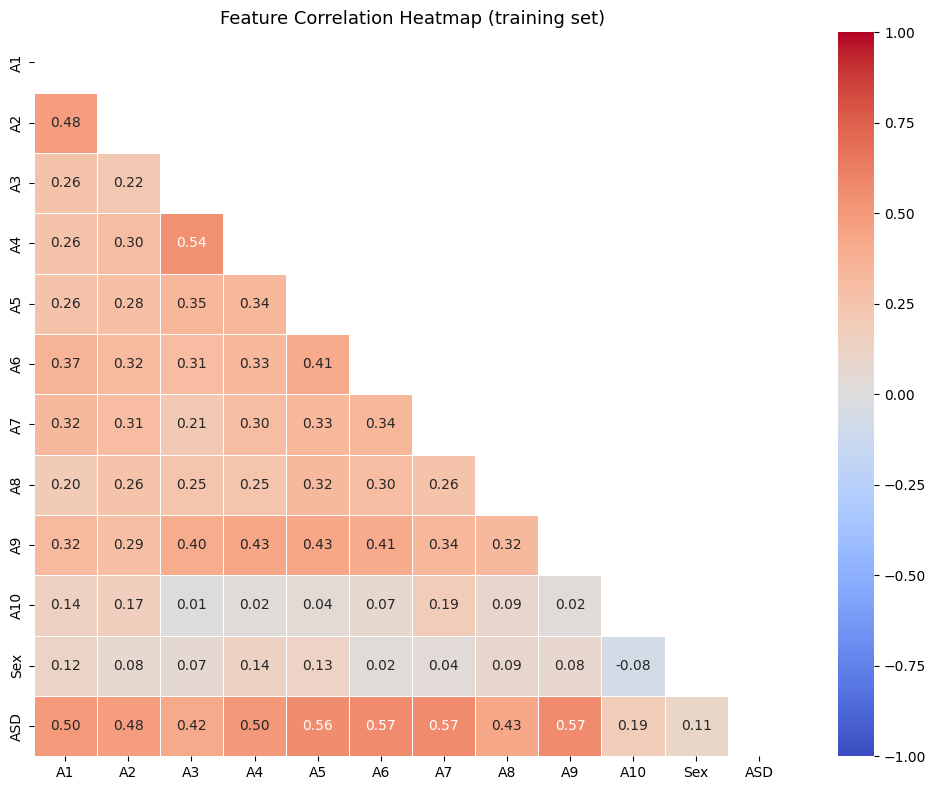

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = X_train.copy()
plot_df["ASD"] = y_train.values
corr = plot_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Heatmap (training set)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

XGBoost Feature Importance

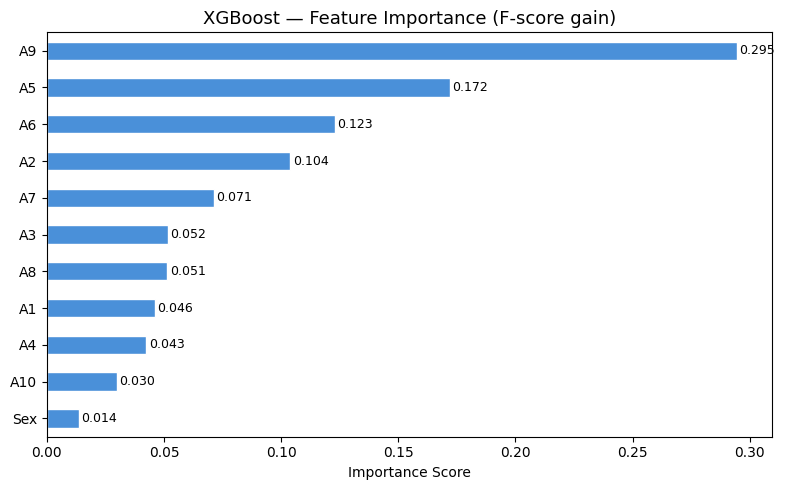

In [ ]:
xgb_model = fitted_models["XGBoost"]
importances = pd.Series(
    xgb_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="#4A90D9", edgecolor="white")
ax.set_title("XGBoost — Feature Importance (F-score gain)", fontsize=13)
ax.set_xlabel("Importance Score")
for i, v in enumerate(importances.values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

**ROC Curve + Confusion Matrix (XGBoost)**

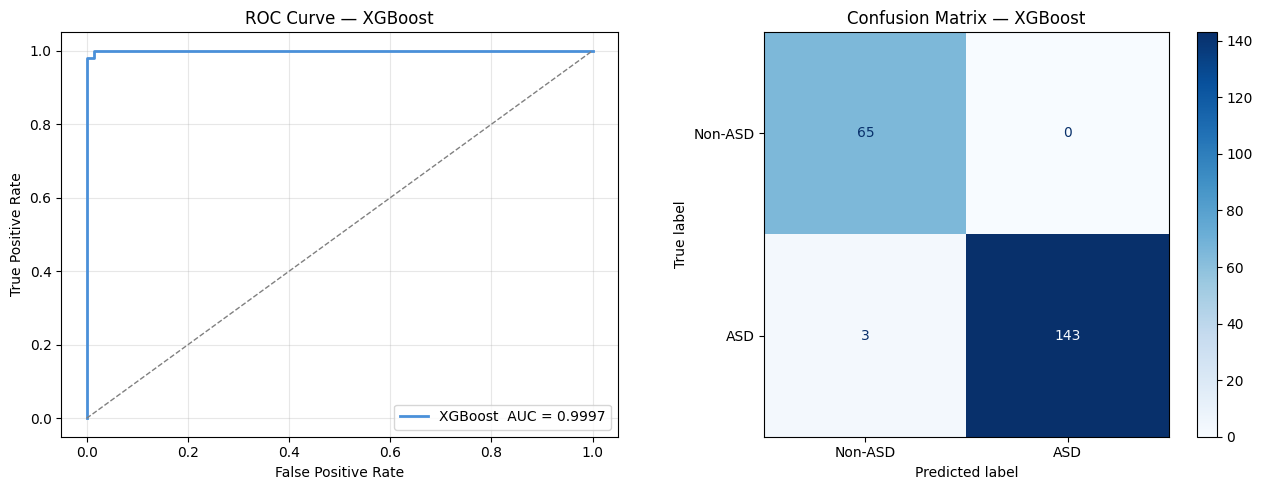

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC Curve ──
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, lw=2, color="#4A90D9",
             label=f"XGBoost  AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — XGBoost")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# ── Confusion Matrix ──
y_pred_xgb = xgb_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-ASD", "ASD"])
disp.plot(cmap="Blues", ax=axes[1], values_format="d")
axes[1].set_title("Confusion Matrix — XGBoost")

plt.tight_layout()
plt.savefig("roc_confusion.png", dpi=150)
plt.show()

In [ ]:
# All metrics printed dynamically — computed from actual predictions

r = results["XGBoost"]
print(classification_report(y_test, y_pred_xgb, target_names=["Non-ASD", "ASD"]))
print("=" * 50)
print("BEST MODEL: XGBoost Classifier")
print("=" * 50)
print(f"Accuracy  : {r['accuracy']:.4f}")
print(f"Precision : {r['precision']:.4f}  (macro)")
print(f"Recall    : {r['recall']:.4f}  (macro)")
print(f"F1-Score  : {r['f1']:.4f}  (macro)")
print(f"AUC-ROC   : {roc_auc:.4f}")
print("=" * 50)

              precision    recall  f1-score   support

     Non-ASD       0.96      1.00      0.98        65
         ASD       1.00      0.98      0.99       146

    accuracy                           0.99       211
   macro avg       0.98      0.99      0.98       211
weighted avg       0.99      0.99      0.99       211

BEST MODEL: XGBoost Classifier
Accuracy  : 0.9858
Precision : 0.9779  (macro)
Recall    : 0.9897  (macro)
F1-Score  : 0.9835  (macro)
AUC-ROC   : 0.9997


Cross-Validation Plot

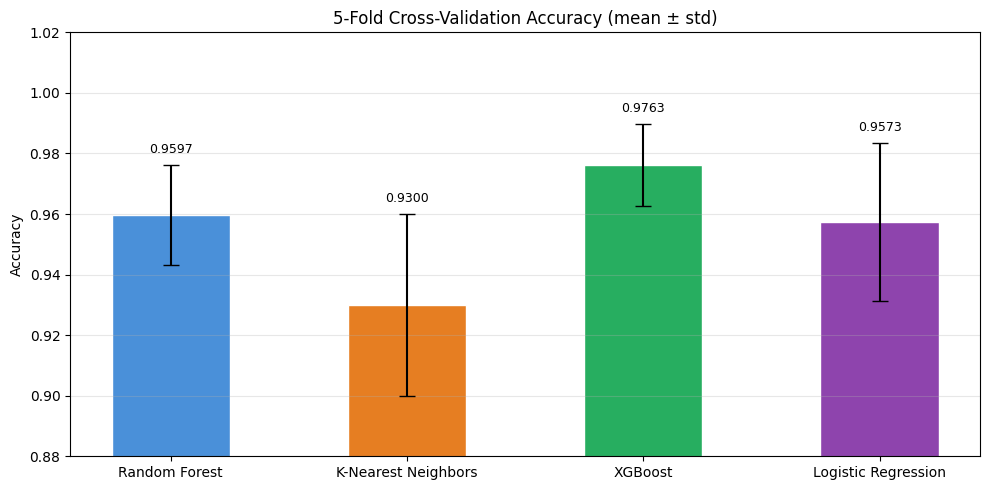

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
cv_names  = list(cv_results.keys())
cv_means  = [cv_results[n]["test_accuracy"].mean() for n in cv_names]
cv_stds   = [cv_results[n]["test_accuracy"].std()  for n in cv_names]
colors    = ["#4A90D9", "#E67E22", "#27AE60", "#8E44AD"]

bars = ax.bar(cv_names, cv_means, yerr=cv_stds, capsize=6,
              color=colors, edgecolor="white", width=0.5)
ax.set_ylim(0.88, 1.02)
ax.set_ylabel("Accuracy")
ax.set_title("5-Fold Cross-Validation Accuracy (mean ± std)")
for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.003,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cv_results.png", dpi=150)
plt.show()

Save Model & Feature List

In [ ]:
os.makedirs("saved_models", exist_ok=True)

# FIX: Save model with joblib (consistent with loading)
joblib.dump(xgb_model, "saved_models/xgboost_asd_model.pkl")

# Save feature column order — agent uses this to guarantee correct order at inference
with open("saved_models/feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f)

print("Saved:")
print("  saved_models/xgboost_asd_model.pkl  — XGBoost model")
print("  saved_models/feature_cols.json      — feature order for agent")

Saved:
  saved_models/xgboost_asd_model.pkl  — XGBoost model
  saved_models/feature_cols.json      — feature order for agent


Sanity Check — Load Model & Predict

In [ ]:
# Load saved model and feature list
loaded_model    = joblib.load("saved_models/xgboost_asd_model.pkl")
with open("saved_models/feature_cols.json") as f:
    loaded_features = json.load(f)

print("Model n_features_in_:", loaded_model.n_features_in_)
print("Feature order       :", loaded_features)

# Sample parent input: [A1,A2,A3,A4,A5,A6,A7,A8,A9,A10, Sex]
sample_raw = [0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0]

# Always use a named DataFrame to guarantee correct feature order
sample_df  = pd.DataFrame([sample_raw], columns=loaded_features)
proba      = loaded_model.predict_proba(sample_df)[0]
pred       = int(np.argmax(proba))
label      = "ASD" if pred == 1 else "Non-ASD"

print(f"\nSample input  : {sample_raw}")
print(f"Prediction    : {label}")
print(f"Confidence    : {proba[pred]*100:.1f}%  "
      f"(ASD: {proba[1]*100:.1f}% | Non-ASD: {proba[0]*100:.1f}%)")
print("\nSanity check passed.")


Model n_features_in_: 11
Feature order       : ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Sex']

Sample input  : [0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0]
Prediction    : ASD
Confidence    : 95.1%  (ASD: 95.1% | Non-ASD: 4.9%)

Sanity check passed.
